# 7. Fine-tuning to follow instructions
## 7.1 Introduction to instruction fine-tuning
## 7.2 Preparing a dataset for supervised instruction finte-tuning

In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:                                                #1
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [2]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a reponse that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    return instruction_text + input_text

In [3]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [4]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['output']}"
print(model_input + desired_response)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [5]:
train_portion = int(len(data) * 0.85)    
test_portion = int(len(data) * 0.1)            
val_portion = len(data) - train_portion - test_portion    

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 Organizing data into training batches

In [6]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):

    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))
    
    def __getitem__(self, idx):
        return self.encoded_texts[idx]

    def __len__(self):
        return len(self.data)

In [7]:
def custom_collate_draft_1(batch, pad_token_id=50256, device='mps'):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

inputs_1=  [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs3 = [7, 8, 9]
batch = [inputs_1, inputs_2, inputs3]
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0')


In [8]:
def custom_collate_draft_2(
    batch, pad_token_id=50256, device='mps'
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, target_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        target = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        target_lst.append(target)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    target_tensor = torch.stack(target_lst).to(device)
    return inputs_tensor, target_tensor

print(custom_collate_draft_2(batch))

(tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0'), tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]], device='mps:0'))


In [9]:
def custom_collate_fn(
    batch, 
    pad_token_id=50256, 
    ignore_index=-100,
    allowed_max_length=None,  
    device='mps'
):
    batch_max_length = max(len(item) + 1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)
    
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='mps:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]], device='mps:0')


## 7.4 Creating data loaders for an instruction dataset

In [10]:
from functools import partial
customized_collate_fn = partial(
    custom_collate_fn, 
    allowed_max_length=1024, 
    device='mps'
)

In [11]:
from torch.utils.data import DataLoader
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers,
)

In [21]:
for inputs, targets in train_loader:
    print(inputs, targets)
    break

tensor([[21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  1128,  2591,   326, 20431, 32543,   262,  2581,    13,   198,
           198, 21017, 46486,    25,   198, 30003,  6525,   262,  1708,  6827,
           523,   326,   340,   318,   287,  4075,  3809,    13,   198,   198,
         21017, 23412,    25,   198,   464, 12187,   373, 22979,   416, 10490,
            13,   198,   198, 21017, 18261,    25,   198, 29284, 22979,   262,
         12187,    13],
        [21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
           257,  1128,  2591,   326, 20431, 32543,   262,  2581,    13,   198,
           198, 21017, 46486,    25,   198,  2061,   318,   262, 22918,   286,
         26600,    30,   198,   198, 21017, 18261,    25,   198,   464, 22918,
           286, 26600,   318,  6032,  1088,   362,    13,    20,    13, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256],
    

## 7.5 Loading a pre-trained LLm

In [12]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-small (124M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size=model_size, 
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [13]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [14]:
from previous_chapters import generate, text_to_token_ids, token_ids_to_text

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [15]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Instruction:

Convert the active


## 7.6 Fine-tuning the LLM on instruction data

In [16]:
from previous_chapters import calc_loss_loader, train_model_simple

In [17]:
device = 'mps'

model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches=5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches=5
)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 4.1742016792297365
Validation loss: 4.058404636383057


In [18]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 4.213, Val loss 4.117
Ep 1 (Step 000005): Train loss 4.324, Val loss 4.199
Ep 1 (Step 000010): Train loss 4.134, Val loss 4.174
Ep 1 (Step 000015): Train loss 4.224, Val loss 4.207
Ep 1 (Step 000020): Train loss 4.175, Val loss 4.208
Ep 1 (Step 000025): Train loss 4.134, Val loss 4.195
Ep 1 (Step 000030): Train loss 4.160, Val loss 4.111
Ep 1 (Step 000035): Train loss 4.016, Val loss 4.039
Ep 1 (Step 000040): Train loss 4.005, Val loss 3.947
Ep 1 (Step 000045): Train loss 3.824, Val loss 3.838
Ep 1 (Step 000050): Train loss 3.771, Val loss 3.759
Ep 1 (Step 000055): Train loss 3.786, Val loss 3.687
Ep 1 (Step 000060): Train loss 3.684, Val loss 3.613
Ep 1 (Step 000065): Train loss 3.537, Val loss 3.542
Ep 1 (Step 000070): Train loss 3.464, Val loss 3.472
Ep 1 (Step 000075): Train loss 3.407, Val loss 3.403
Ep 1 (Step 000080): Train loss 3.392, Val loss 3.336
Ep 1 (Step 000085): Train loss 3.273, Val loss 3.270
Ep 1 (Step 000090): Train loss 3.213, Val loss

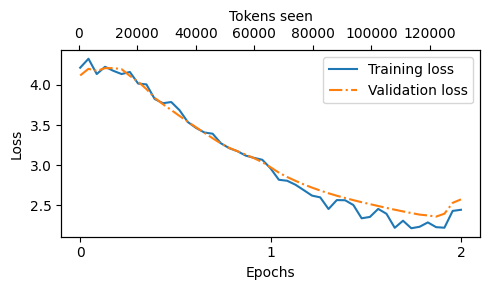

In [19]:
from previous_chapters import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [20]:
torch.manual_seed(123)

for entry in test_data[:3]:      #1
    input_text = format_input(entry)
    token_ids = generate(               #2
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)

    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )
    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")


Below is an instruction that describes a task. Write a reponse that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> ### Output:

The sentence is very fast.

### Write a reponse that completes the request.

### Write a reponse that completes the request.

### Write a reponse that completes the request.

### Write a reponse that completes the Response.

### Write a reponse that completes the request.

### Write a Response that completes the request.

### Write a Response.

### Write a Response.

### Write a Response.

### Response.

### Write a Response.

### Write a Response.

### Write a Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

### Response.

#